<a href="https://colab.research.google.com/github/scelliot-cpu/Elliott_DSPN_26/blob/master/ExerciseSubmissions/17_regularized-regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 17: Regularized regression

This homework assignment is designed to give you an intuition as an interesting property of regularization in the context of ultra-high dimensional statistical problems.

You won't need to load in any data for this homework.

---
## 1. Simulating & visualizing data (2 points)

We are going to be looking at what happens in the context where $p>n$. In order to have total control over our data, we will use simulations for this homework. First, we will need to load the `glmnet`, `tidyverse`, and `ggplot2` libraries for this assignment.


In [2]:
install.packages("glmnet")
install.packages("tidyverse")
install.packages("ggplot2")

library(glmnet)
library(tidyverse)
library(ggplot2)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘iterators’, ‘foreach’, ‘shape’, ‘RcppEigen’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Loading required package: Matrix

Loaded glmnet 4.1-10

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ tidyr::expand() masks Matrix::expand()
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
✖ tidyr::pack()   masks Matrix::pack()
✖ tidyr::unpack() masks Matrix::unpack()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force a

We are going to generate a data set with complex structure and try to recover it using polynomial models. For simplicity sake, use the following code to produce a response variable, $y$ that has complex structure.

*Hint: Look up what a cosine function looks like if you need a reminder.*

In [3]:
# Generate data
set.seed(121)
sigma_noise = .5
x=seq(-9,9,by=.18)
n=length(x)
y = 0.1*x + cos(x) + cos(x/20)+rnorm(n,sd=sigma_noise)

(a) Break the data into a training set (n=50) and test set (n=51) using the `sample` function to randomly select subsets of x and y.  Make a separate data frame for the training and test data.

(**Note**: *Do not* just take the first 50 observations to be the training set and last 51 observations to be the test set.)

In [4]:
set.seed(1)

train = sample(1:length(y), 50)
test = (-train)

train_data = data.frame(x = x[train], y = y[train])
test_data = data.frame(x = x[test], y = y[test])

(b) Plot the training data ($x$ \& $y$). Describe the relationship that you see in the training data.

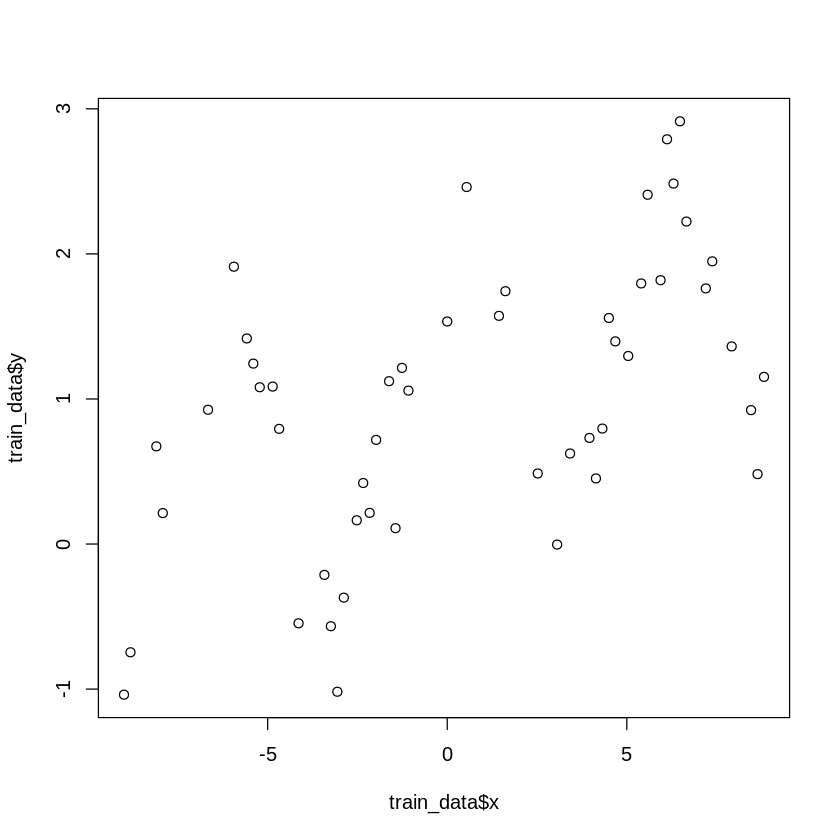

In [10]:
plot(train_data$x, train_data$y)

How would you describe the relationship between $x$ and $y$ based on this plot?

> *There is a weak positive relationship between $x$ and $y$.*

---
## 2. Bias-variance tradeoff: polynomial regression (4 points)

Recall that in polynomial regression we increase model complexity by expanding $x$ out to the power $k$ (which we call degree).

$$
Y = \hat{\beta}_0 + \sum_{j=1}^K \hat{\beta}_j X^j
\;=\; \operatorname{poly}(X, K)
$$

(a) Fit a 2nd degree polynomial regression model to the training data. Plot the results.


*Hint: Use the* `help` *function to see how to use the* `stat_smooth()` *and* `poly()` *functions.*

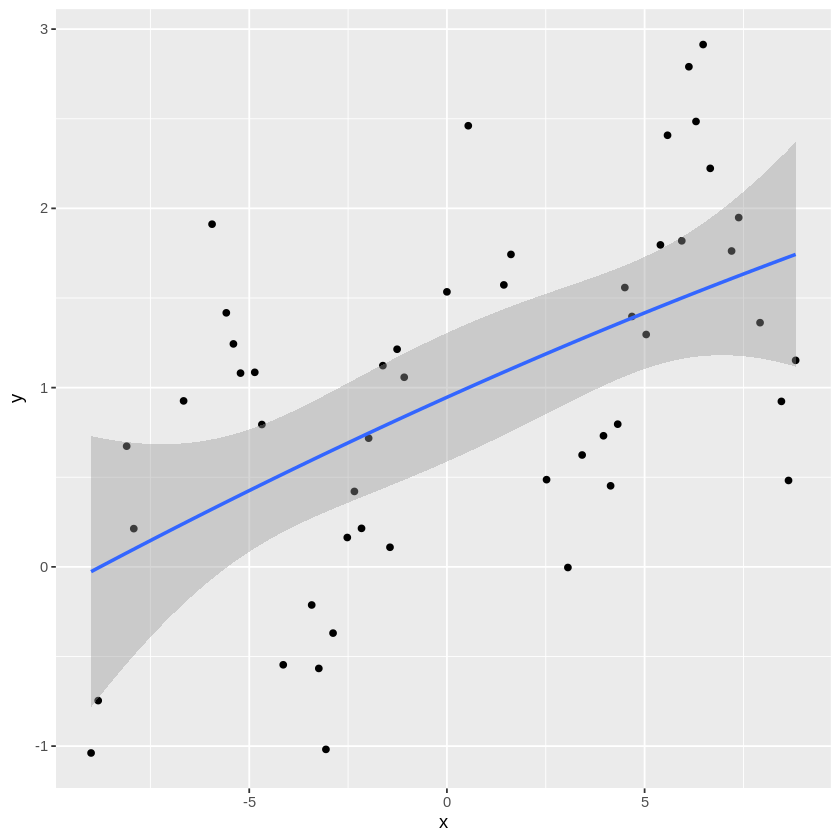

In [12]:
ggplot(train_data, aes(x = x, y = y)) +
  geom_point() +
  stat_smooth(method = "lm", formula = y ~ poly(x, 2))

How well does this 2nd degree polynomial model qualitatively fit the data? Could it do better?

> *The model fits pretty well but doesn't capture all the variation. It could do better with a higher degree polynomial.*
>

(b) Fit a 12th degree polynomial to the data. Does this do qualitatively better or worse than the 2nd degree model?

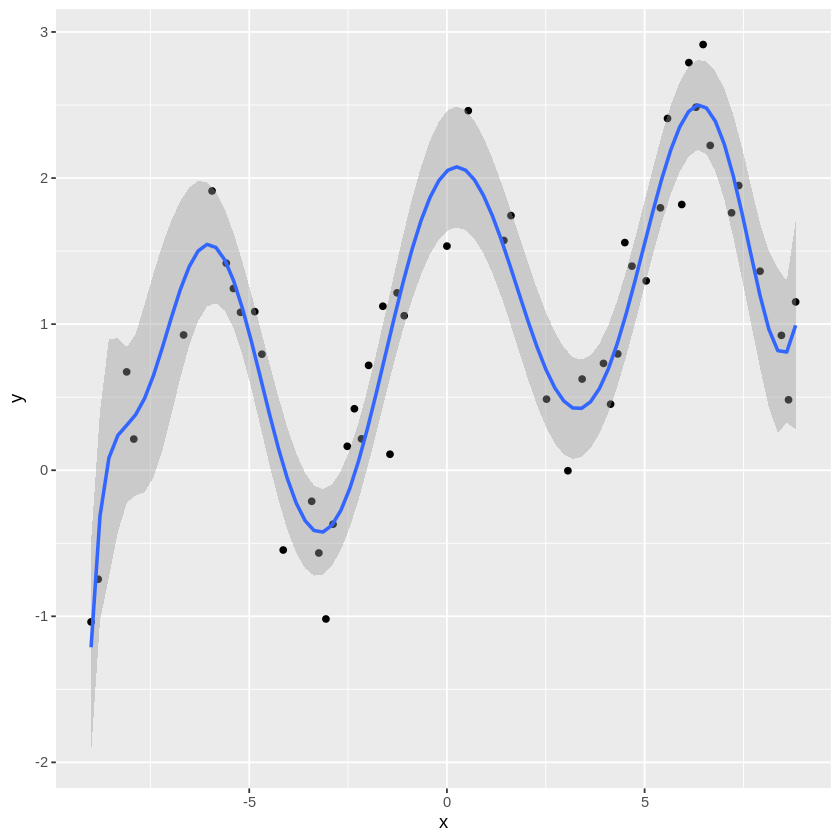

In [14]:
ggplot(train_data, aes(x = x, y = y)) +
  geom_point() +
  stat_smooth(method = "lm", formula = y ~ poly(x, 12))

> *I believe this fits worse because it fits the training data very closely to the point that it appears to overfit the data so it is capturing noise rather than the actual pattern.*
>

(c) Modify the loop below to estimate the bias-variance tradeoff as model complexity (i.e., degree of the polynomial model, $k$) increases from 2 to 50. Use the training data to fit the model and test data to evaluate its predictive accuracy.

Visualize your results by plotting the *median* squared error for the training data and test data as a function of polynomial degree.


(**Note**: We are using median accuracies here because there are often 1 or 2 outlier values in the higher degree polynomial models that can throw off the accuracy estimates).

Warning message in predict.lm(fit, newdata = train_data):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(fit, newdata = test_data):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(fit, newdata = train_data):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(fit, newdata = test_data):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(fit, newdata = train_data):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(fit, newdata = test_data):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(fit, newdata = train_data):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(fit, newdata = test_d

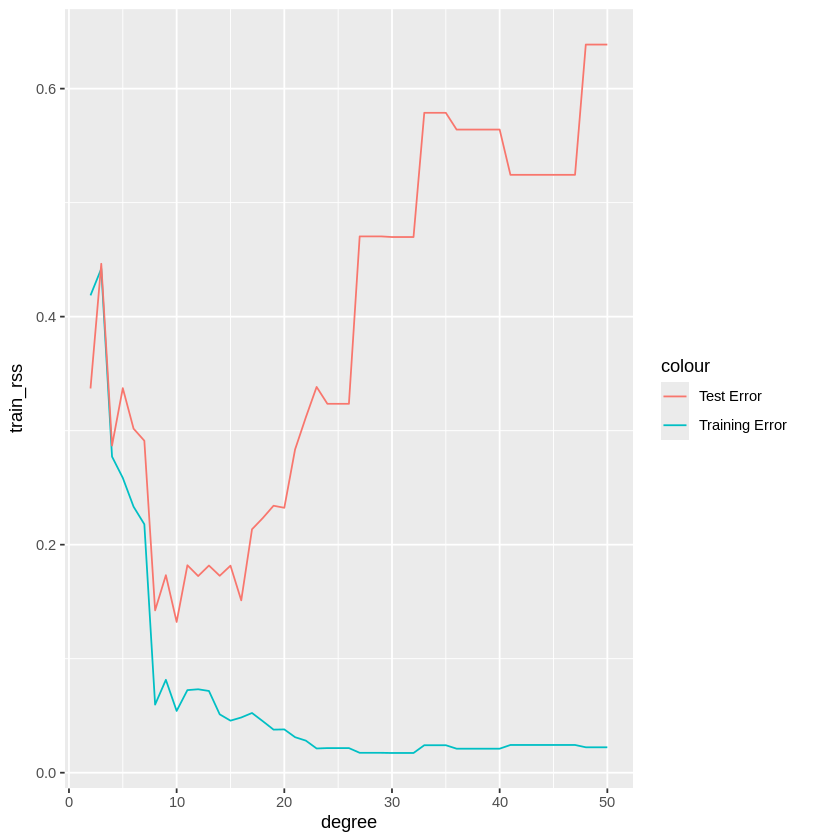

In [24]:
# Now do the variance-bias trade off analysis using regular regression
degree = seq(2,50)

# Need to setup your output vectors
train_rss = matrix(data=NA,nrow=length(degree),ncol=1)
test_rss = matrix(data=NA,nrow=length(degree),ncol=1)

for (k in degree) {
  fit = lm(y ~ poly(x, k, raw = TRUE), data = train_data)

  train_pred = predict(fit, newdata = train_data)
  test_pred = predict(fit, newdata = test_data)

  train_rss[k-1, 1] = median((train_data$y - train_pred)^2)
  test_rss[k-1, 1] = median((test_data$y - test_pred)^2)

}

# Plot your results here
results <- data.frame(
  degree = degree,
  train_rss = train_rss,
  test_rss = test_rss
)
ggplot(results, aes(x = degree)) +
  geom_line(aes(y = train_rss, color = "Training Error")) +
  geom_line(aes(y = test_rss, color = "Test Error"))

What do you see as $k$ increase?

> *As k increases, the training error decreases towards zero. The testing error initially starts to decreases, reaches a minimum around 10 and then increases.*
>

(d) Now copy the code above and let's see what happens when we go beyond $p=n$ (remember, in this case $k=p$). Test polynomial models up to $k=150$. Visualize your results by plotting the *median* squared error for the training data and test data as a function of polynomial degree.

Use the `geom_vline()` function in `ggplot` to draw a vertical line where $k=n$ (here $n$ is the number of observations in the training set). This will make it clear where we cross the threshold for finding *unique* solutions in our data.



Warning message in predict.lm(fit, newdata = train_data):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(fit, newdata = test_data):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(fit, newdata = train_data):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(fit, newdata = test_data):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(fit, newdata = train_data):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(fit, newdata = test_data):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(fit, newdata = train_data):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(fit, newdata = test_d

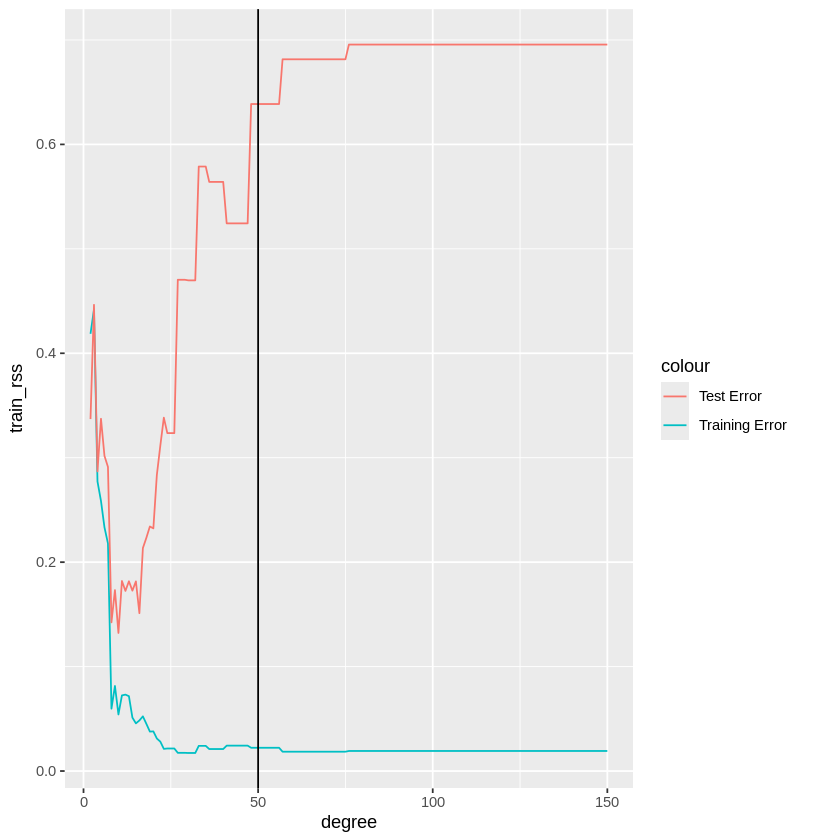

In [25]:
degree = seq(2,150)

train_rss = matrix(data=NA,nrow=length(degree),ncol=1)
test_rss = matrix(data=NA,nrow=length(degree),ncol=1)

for (k in degree) {
  fit = lm(y ~ poly(x, k, raw = TRUE), data = train_data)

  train_pred = predict(fit, newdata = train_data)
  test_pred = predict(fit, newdata = test_data)

  train_rss[k-1, 1] = median((train_data$y - train_pred)^2)
  test_rss[k-1, 1] = median((test_data$y - test_pred)^2)
}

results <- data.frame(
  degree = degree,
  train_rss = train_rss,
  test_rss = test_rss
)

ggplot(results, aes(x = degree)) +
  geom_line(aes(y = train_rss, color = "Training Error")) +
  geom_line(aes(y = test_rss, color = "Test Error")) +
  geom_vline(xintercept = 50)

What do you see as $k$ gets larger than $n$?

> *As k gets larger than n, the training errors remains extremely low, while the testing error becomes very larger showing severe overfitting.*
>

---
## 3. Applying regularization to the model fits (2 points)

Repeat the previous bias-variance tradeoff test, going up to $k=150$, but now use ridge regression with a sparsity parameter of $\lambda=0.00005$. Plot your results the same way as last time.

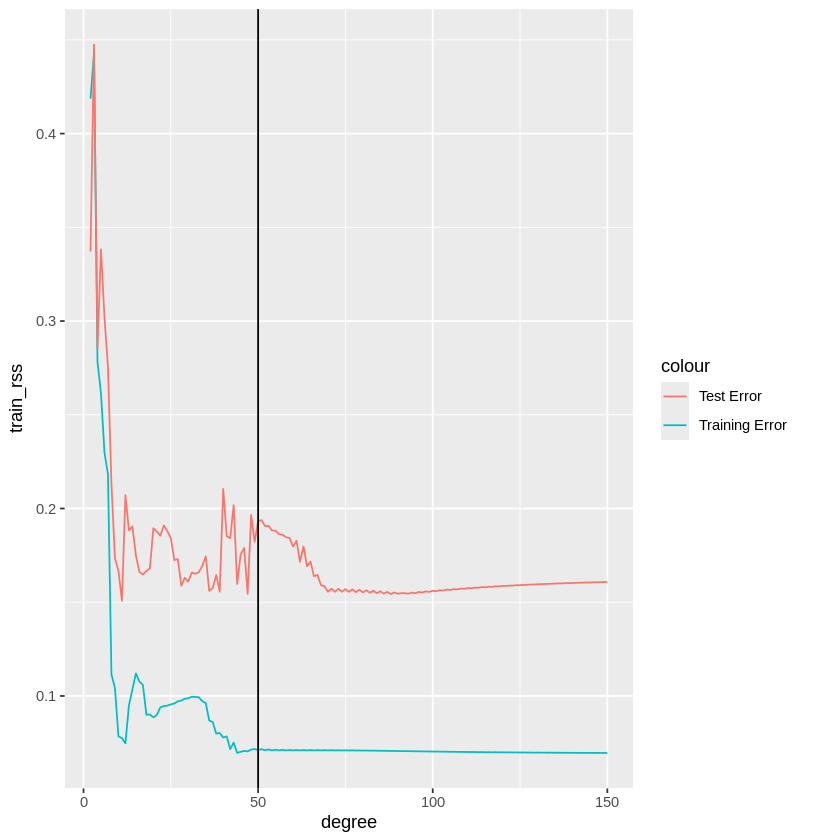

In [26]:
# Now do the variance-bias trade off analysis using ridge regression
lambda=0.00005
degree = seq(2,150)

rm(train_rss, test_rss)
train_rss = matrix(data=NA,nrow=length(degree),ncol=1)
test_rss = matrix(data=NA,nrow=length(degree),ncol=1)

for (k in degree) {
    x_train = model.matrix(y ~ poly(x, k, raw = TRUE), data = train_data)[,-1]
    x_test = model.matrix(y ~ poly(x, k, raw = TRUE), data = test_data)[,-1]

    ridge.mod = glmnet(x_train, train_data$y, alpha = 0, lambda = lambda)

    train_pred = predict(ridge.mod, s = lambda, newx = x_train)
    test_pred = predict(ridge.mod, s = lambda, newx = x_test)

    train_rss[k-1, 1] = median((train_data$y - train_pred)^2)
    test_rss[k-1, 1] = median((test_data$y - test_pred)^2)

}

# Plot your results here
results <- data.frame(
  degree = degree,
  train_rss = train_rss,
  test_rss = test_rss
)

ggplot(results, aes(x = degree)) +
  geom_line(aes(y = train_rss, color = "Training Error")) +
  geom_line(aes(y = test_rss, color = "Test Error")) +
  geom_vline(xintercept = 50)


What happens now when $k$ gets larger than $n$?

> *Now, when k gets larger than n, the test error does not increase dramatically and is much more stable showing that the ridge regression helped to control overfitting.*
>

---
## 4. Reflection (2 points)

The simulations above should have shown that, when applying a regularization (i.e., a sparsity constraint), the behavior of the bias-variance tradeoff changes. Explain why this happens.

> *The regularization prevents coefficients from becoming very large as model complexity increases, reducing the variance and stabilizing the model. This especially happens at k > n. The model is less prone to overfitting so we don't see that increase in test error. This does come at the cost of increasing bias.*
>

---
## Bonus (1 extra credit point)
Recall that the $p=n$ threshold defines the limit for finding a *unique* solution to $Y=F(X)$ (i.e., there is only one combination of regression coefficients that is *best* at explaining variance in $Y$). With this in mind, what is regularization doing that works around this upper limit?

> *Write your response here*
>

**DUE:** 11:59pm EST, April 7, 2026

**IMPORTANT** Did you collaborate with anyone on this assignment? If so, list their names here.
> *Worked with Tina on question 2c.*